In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Iris.csv")
print(df)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [ ]:
# No Nan

    Age   Salary
0  44.0  72000.0
1  27.0  48000.0
2  30.0  54000.0
3  38.0  61000.0
4  40.0  48000.0


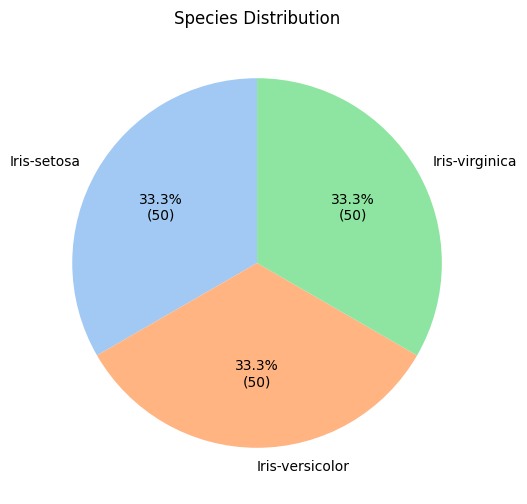

In [5]:
# Metric pie chart cho cot Species
purchased_counts = df['Species'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    purchased_counts,
    labels=purchased_counts.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct / 100 * purchased_counts.sum()))})",
    startangle=90,
    colors=sns.color_palette('pastel', len(purchased_counts)),
)
plt.title('Species Distribution')
plt.ylabel('')
plt.show()

In [15]:
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

print(X.head())
print(y.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str


In [16]:
# Mapping text -> number for Species column
codes, uniques = pd.factorize(y)
y = pd.Series(codes, name='Species')
species_mapping = {cat: int(i) for i, cat in enumerate(uniques)}

print("Species mapping:", species_mapping)
print(X.head())
print(y.head())

Species mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2
0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer

# Normalize feature columns
sc = Normalizer()
X_norm = sc.fit_transform(X)

# Species la target label 0/1/2, khong normalize target cho bai toan classification
y_norm = y.to_numpy()

print(X_norm)
print(y_norm)

# Data spliting: Training - Test set
x_train, x_test, y_train, y_test = train_test_split(
    X_norm, y_norm, test_size=0.3, random_state=42
)

print("X Train: ", x_train)
print("Y Train: ", y_train)

[[0.80377277 0.55160877 0.22064351 0.0315205 ]
 [0.82813287 0.50702013 0.23660939 0.03380134]
 [0.80533308 0.54831188 0.2227517  0.03426949]
 [0.80003025 0.53915082 0.26087943 0.03478392]
 [0.790965   0.5694948  0.2214702  0.0316386 ]
 [0.78417499 0.5663486  0.2468699  0.05808704]
 [0.78010936 0.57660257 0.23742459 0.0508767 ]
 [0.80218492 0.54548574 0.24065548 0.0320874 ]
 [0.80642366 0.5315065  0.25658935 0.03665562]
 [0.81803119 0.51752994 0.25041771 0.01669451]
 [0.80373519 0.55070744 0.22325977 0.02976797]
 [0.786991   0.55745196 0.26233033 0.03279129]
 [0.82307218 0.51442011 0.24006272 0.01714734]
 [0.8025126  0.55989251 0.20529392 0.01866308]
 [0.81120865 0.55945424 0.16783627 0.02797271]
 [0.77381111 0.59732787 0.2036345  0.05430253]
 [0.79428944 0.57365349 0.19121783 0.05883625]
 [0.80327412 0.55126656 0.22050662 0.04725142]
 [0.8068282  0.53788547 0.24063297 0.04246464]
 [0.77964883 0.58091482 0.22930848 0.0458617 ]
 [0.8173379  0.51462016 0.25731008 0.03027177]
 [0.78591858 

Models:  Linear Regression
Accuracy: 0.9555555555555556
Precision: 0.9487179487179488
Recall: 0.9487179487179488
F1 score: 0.9487179487179488
Confusion matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  1 12]]


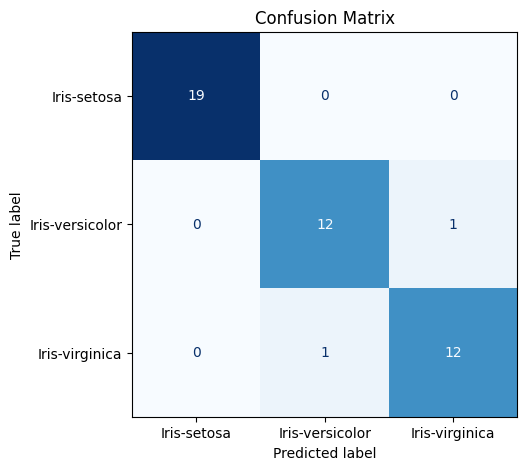

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.92      0.92      0.92        13
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45

Models:  Random Forest
Accuracy: 0.9777777777777777
Precision: 0.9761904761904763
Recall: 0.9743589743589745
F1 score: 0.974320987654321
Confusion matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  1 12]]


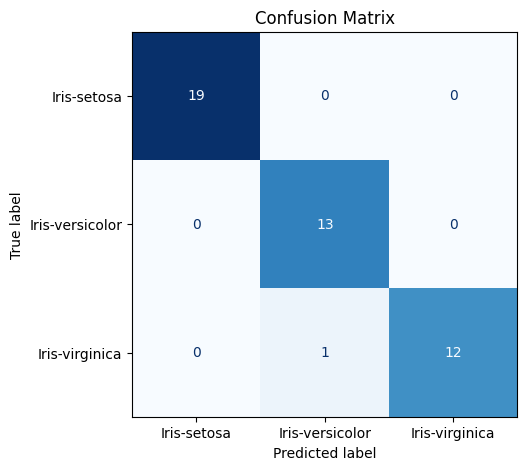

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

Models:  XG Boost
Accuracy: 0.9111111111111111
Precision: 0.903030303030303
Recall: 0.8974358974358975
F1 score: 0.8968253968253969
Confusion matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  3 10]]


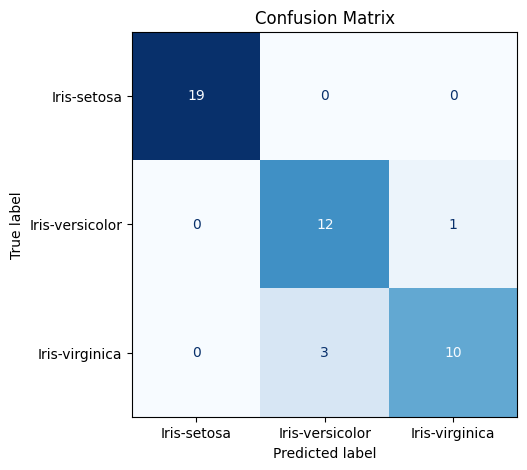

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.80      0.92      0.86        13
           2       0.91      0.77      0.83        13

    accuracy                           0.91        45
   macro avg       0.90      0.90      0.90        45
weighted avg       0.92      0.91      0.91        45



In [26]:
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBModel
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "XG Boost": XGBModel(n_estimators=100),
}


for name, model in models.items():
    model.fit(x_train, y_train)
    Y_predict = model.predict(x_test)
    y_pred = np.rint(Y_predict).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    conf_mat = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    print("Models: ", name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 score:", f1)
    
    print("Confusion matrix:\n", conf_mat)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    target_names = [name for name, _ in sorted(species_mapping.items(), key=lambda x: x[1])]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Confusion Matrix')
    plt.show()
    
    print("Classification report:\n", report)

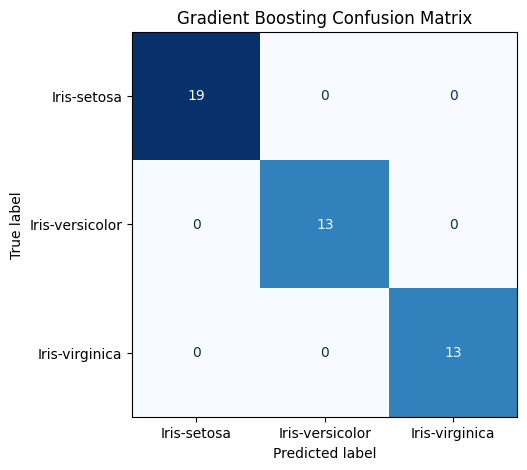

/var/folders/vq/5c8s2nl166b551v0b7g962hr0000gn/T/ipykernel_46723/414831228.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[order], y=feature_names[order], palette='viridis')


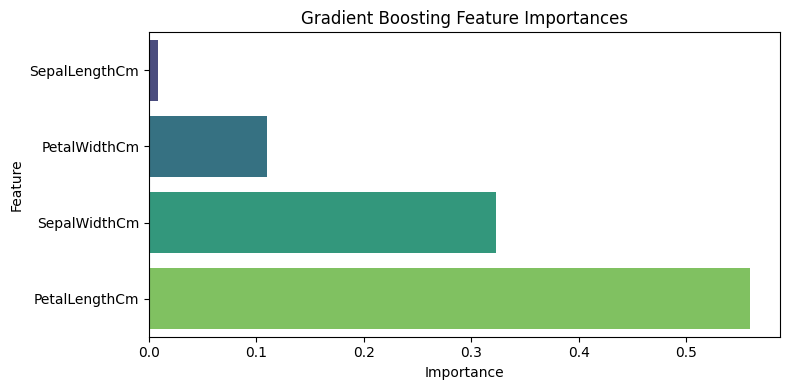

In [23]:
# Visualize Gradient Boosting results with charts
from sklearn.metrics import ConfusionMatrixDisplay

# Use the last trained model from the loop (Gradient Boosting)
y_pred = np.rint(model.predict(x_test)).astype(int)

target_names = [name for name, _ in sorted(species_mapping.items(), key=lambda x: x[1])]

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Gradient Boosting Confusion Matrix')
plt.show()

# Feature importance bar chart
feature_names = X.columns
importances = model.feature_importances_
order = np.argsort(importances)
plt.figure(figsize=(8, 4))
sns.barplot(x=importances[order], y=feature_names[order], palette='viridis')
plt.title('Gradient Boosting Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()